# Live text analyzer to detect unsolicited messages using count vectorizer

## importing libraries.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

%matplotlib inline

## Reading the SMS data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#basepath = '/content/drive/My Drive/SMS_spam_Detection_Project/{}'
basepath = 'C:\\Users\\Hp\\Desktop\\GitSMSSpamDemo1\\SMS-Spam-Detection-Model\\spam Data.csv'

In [ ]:
# from google.colab import files
# sms = files.upload()
# sms.head()

In [11]:
sms = pd.read_csv(basepath.format('spam Data.csv'),encoding='ISO-8859-1')
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Processing

### Delete the unnecessary columns.

In [12]:
cols_to_drop = ['Unnamed: 2','Unnamed: 3','Unnamed: 4']
sms.drop(cols_to_drop,axis=1,inplace=True)
sms.columns = ['label','message']
sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Checking the info of our SMS data.

In [13]:
sms.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


## Declaring Count Vectorizer.

In [14]:
cv = CountVectorizer(decode_error='ignore')
X = cv.fit_transform(sms['message'])

X_train, X_test, y_train, y_test = train_test_split(X, sms['label'], test_size=0.3, random_state=101)

## Creating a Multinomial Naive Bayes model for Spam detection.

In [15]:
mnb = MultinomialNB()
mnb.fit(X_train,y_train)
print('training accuracy is --> ',mnb.score(X_train,y_train)*100)
print('test accuracy is --> ',mnb.score(X_test,y_test)*100)

training accuracy is -->  99.41025641025641
test accuracy is -->  98.56459330143541


# Visualizing the results.

In [16]:
def visualize(label):
    words = ''
    for msg in sms[sms['label']==label]['message']:
        msg = msg.lower()
        words+=msg + ' '
    wordcloud = WordCloud(width=600,height=400).generate(words)
    plt.imshow(wordcloud)
    plt.axis('off')

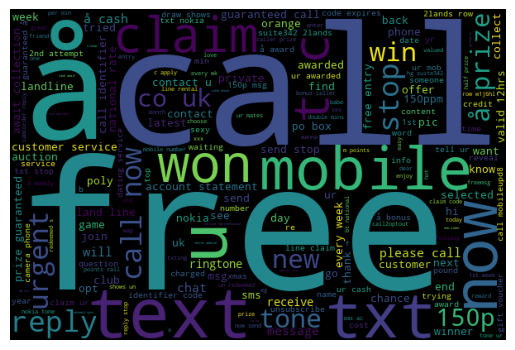

In [17]:
visualize('spam')
#Like here free is the biggest word, and as we know that messages containing free words are mostly SPAM.

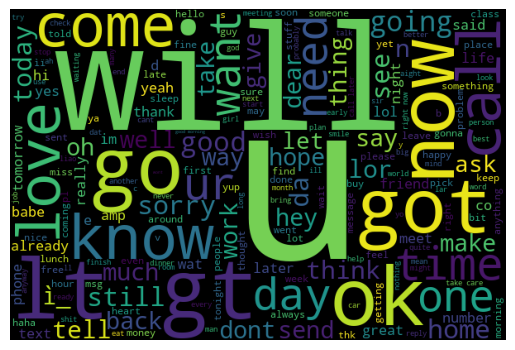

In [18]:
visualize('ham')

## live spam detection

In [34]:
# just type in your message and run
#your_message = 'You are the lucky winner for the lottery price of $6million.'
your_message= 'You won &5000.00 cash prize. To claim your prize call our customer service representative on 09061749602'
your_message = cv.transform([your_message])
classs = mnb.predict(your_message)
print(f'This is a {classs[0]} message')

This is a spam message
